### Verificação de pressupostos

Inicialmente serão avaliados os pressupostos necessários para aplicação do teste t para amostras independentes. Em seguida, será realizado o teste de hipótese e calculado o tamanho do efeito da diferença observada entre os grupos.

In [8]:
# Imports e carregamento do dataset

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro

import statsmodels.api as sm

df = pd.read_csv("../data/df_analytical.csv")

##### Separação dos grupos

In [9]:
grupo_sem_promocao = df[df["HAS_DISPLAY"] == 0]["TOTAL_UNITS"]

grupo_com_promocao = df[df["HAS_DISPLAY"] == 1]["TOTAL_UNITS"]

print(len(grupo_sem_promocao))
print(len(grupo_com_promocao))

13606
47473


Antes da aplicação do teste t para comparação das médias, é necessário verificar se os principais pressupostos do teste são atendidos. Nesta etapa serão avaliadas a normalidade da variável `TOTAL_UNITS` em cada grupo, por meio de inspeção gráfica e do teste de Shapiro-Wilk em uma amostra dos dados, e a homogeneidade das variâncias utilizando o teste de Levene. Esses resultados servirão de base para a escolha da versão mais adequada do teste t.

**Histogramas**

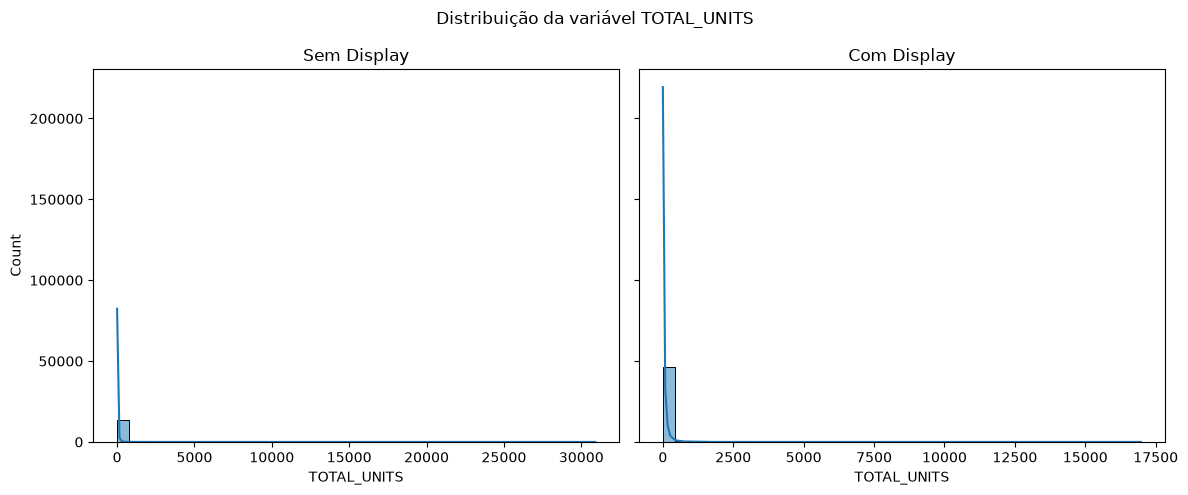

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)

sns.histplot(grupo_sem_promocao, bins=40, kde=True, ax=ax[0])
ax[0].set_title("Sem Display")
ax[0].set_xlabel("TOTAL_UNITS")

sns.histplot(grupo_com_promocao, bins=40, kde=True, ax=ax[1])
ax[1].set_title("Com Display")
ax[1].set_xlabel("TOTAL_UNITS")

plt.suptitle("Distribuição da variável TOTAL_UNITS")
plt.tight_layout()

plt.show()

Os histogramas evidenciam que a variável TOTAL_UNITS apresenta distribuição assimétrica à direita em ambos os grupos, comportamento esperado para dados de vendas. Considerando o elevado tamanho das amostras (13.606 e 47.473 observações), o teste t é considerado robusto à violação da normalidade em função do Teorema Central do Limite.

**Q-Q Plot**

* Iimportante para verificar a normalidade visualmente.

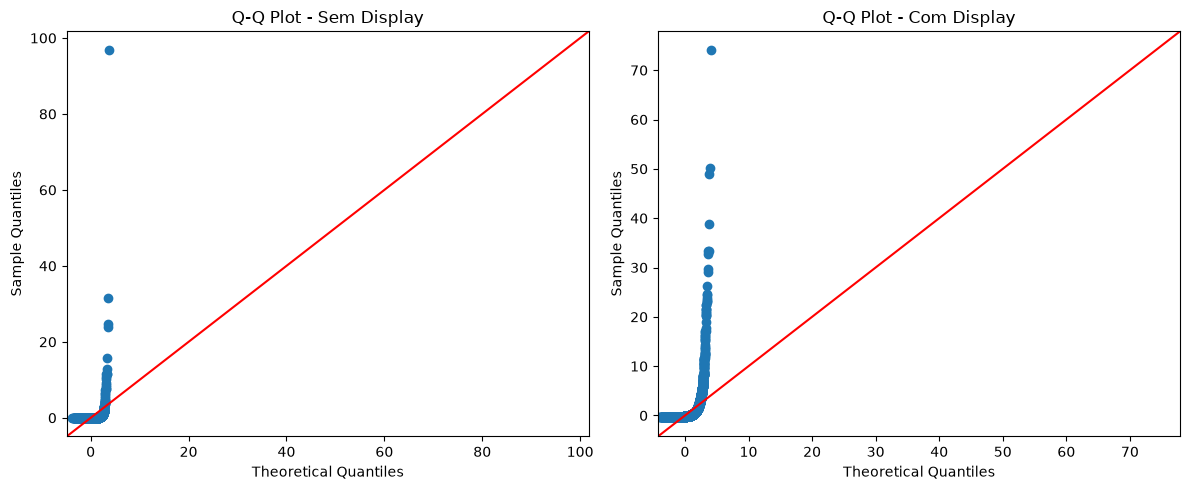

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sm.qqplot(grupo_sem_promocao, line="45", fit=True, ax=ax[0])
ax[0].set_title("Q-Q Plot - Sem Display")

sm.qqplot(grupo_com_promocao, line="45", fit=True, ax=ax[1])
ax[1].set_title("Q-Q Plot - Com Display")

plt.tight_layout()

plt.show()

**Teste de Shapiro-Wilk (amostra)**

* Como o teste não é adequado para dezenas de milhares de observações, fazemos uma amostragem aleatória.

In [12]:
amostra_sem_promocao = grupo_sem_promocao.sample(5000, random_state=42)
amostra_com_promocao = grupo_com_promocao.sample(5000, random_state=42)

stat_sem_promocao, p_sem_promocao = shapiro(amostra_sem_promocao)
stat_com_promocao, p_com_promocao = shapiro(amostra_com_promocao)

print("Grupo sem Display")
print(f"Estatística = {stat_sem_promocao}")
print(f"p-valor = {p_sem_promocao}")

print()

print("Grupo com Display")
print(f"Estatística = {stat_com_promocao}")
print(f"p-valor = {p_com_promocao}")

Grupo sem Display
Estatística = 0.019724495160680415
p-valor = 2.2141754411954317e-95

Grupo com Display
Estatística = 0.14967503546583846
p-valor = 4.7373287045828234e-92


**Homogeneidade das variâncias**

* Aqui usamos Levene.

In [13]:
from scipy.stats import levene

stat, p = levene(
    grupo_sem_promocao,
    grupo_com_promocao
)

print(f"Estatística = {stat}")
print(f"p-valor = {p}")

Estatística = 143.57961119277218
p-valor = 4.7819028899401646e-33


**Resumo dos pressupostos**

In [14]:
resultado_pressupostos = pd.DataFrame({
    "Pressuposto": [
        "Normalidade (Sem Display)",
        "Normalidade (Com Display)",
        "Homogeneidade das variâncias"
    ],
    "Teste": [
        "Shapiro-Wilk",
        "Shapiro-Wilk",
        "Levene"
    ],
    "p-valor": [
        p_sem_promocao,
        p_com_promocao,
        p
    ]
})

resultado_pressupostos

,Pressuposto,Teste,p-valor
0,Normalidade (Sem Display),Shapiro-Wilk,2.214175e-95
1,Normalidade (Com Display),Shapiro-Wilk,4.737329e-92
2,Homogeneidade das variâncias,Levene,4.781903e-33


Os histogramas e gráficos Q-Q evidenciaram que a variável TOTAL_UNITS apresenta distribuição assimétrica e presença de valores extremos em ambos os grupos. Os testes de Shapiro-Wilk confirmaram a ausência de normalidade (p < 0,05), enquanto o teste de Levene indicou variâncias diferentes entre os grupos (p < 0,05).

Apesar dessas violações, o elevado tamanho das amostras (13.606 e 47.473 produtos) permite a aplicação de testes paramétricos. Assim, será utilizado o teste t de Welch, por ser mais adequado para comparar médias entre grupos com variâncias distintas.